In [1]:
!pip install pandas openpyxl xlsxwriter matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.8 MB/s eta 0:00:00


In [5]:
import pandas as pd

# Load dataset
file_path = "/Blinkit-sales-Dashboard.xlsx"

df = pd.read_excel(file_path, sheet_name="BlinkIT Grocery Data")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (8523, 13)


,Item Fat Content,SR No.,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,1,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,2,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,3,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,4,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,5,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# DATA OVERVIEW
# -----------------------------

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (8523, 13)

Columns:
Index(['Item Fat Content', 'SR No.', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   SR No.                     8523 non-null   int64  
 2   Item Identifier            8523 non-null   object 
 3   Item Type                  8523 non-null   object 
 4   Outlet Establishment Year  8523 non-null   int64  
 5   Outlet Identifier          8523 non-null   object 
 6   Outlet Location Type       8523 non-null   object 
 7   Outlet Size                8523 non-null   object 
 8   Outlet 

# BASIC SALES METRICS


In [7]:
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
max_sales = df["Sales"].max()

print("\nTotal Sales:", total_sales)
print("Average Sales:", average_sales)
print("Maximum Sales:", max_sales)



Total Sales: 1201681.4928
Average Sales: 140.99278338613163
Maximum Sales: 266.8884


# SALES BY ITEM TYPE

In [8]:
sales_by_item = (
    df.groupby("Item Type")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Selling Item Categories:")
print(sales_by_item.head(10))


Top Selling Item Categories:
Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9224
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4616
Canned                    90706.7290
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1670
Name: Sales, dtype: float64


# SALES BY OUTLET LOCATION

In [9]:
sales_by_location = (
    df.groupby("Outlet Location Type")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nSales by Outlet Location:")
print(sales_by_location)



Sales by Outlet Location:
Outlet Location Type
Tier 3    472133.0332
Tier 2    393150.6476
Tier 1    336397.8120
Name: Sales, dtype: float64


# SALES BY OUTLET TYPE


In [10]:
sales_by_outlet = (
    df.groupby("Outlet Type")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nSales by Outlet Type:")
print(sales_by_outlet)


Sales by Outlet Type:
Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64


# CUSTOMER RATING ANALYSIS

In [11]:
rating_analysis = (
    df.groupby("Item Type")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Rating by Item Type:")
print(rating_analysis.head(10))


Average Rating by Item Type:
Item Type
Meat                     4.023059
Household                3.998681
Canned                   3.994299
Health and Hygiene       3.986154
Baking Goods             3.983025
Frozen Foods             3.971145
Dairy                    3.965836
Seafood                  3.959375
Fruits and Vegetables    3.956169
Others                   3.954438
Name: Rating, dtype: float64


# VISUALIZATIONS

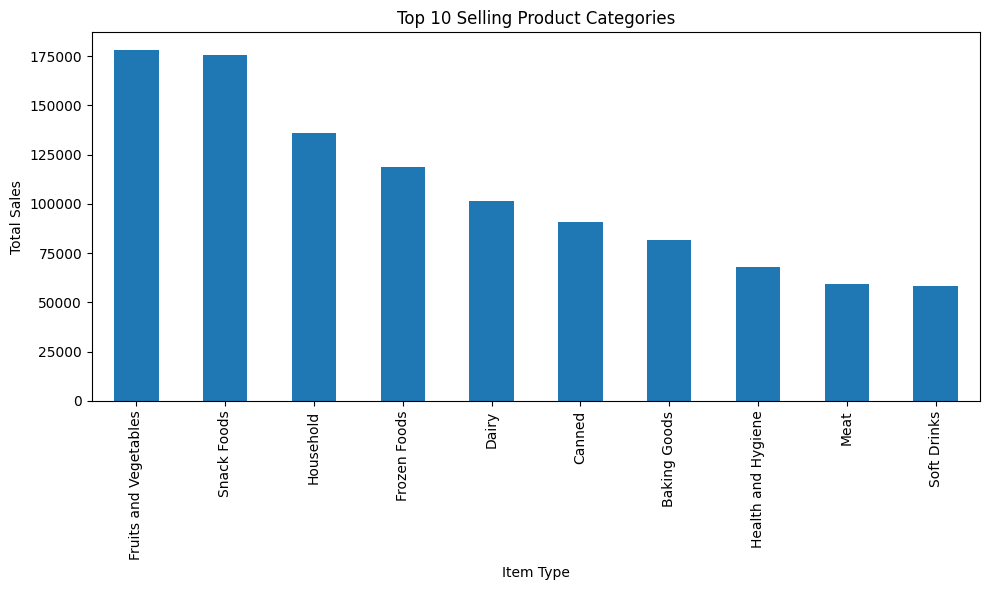

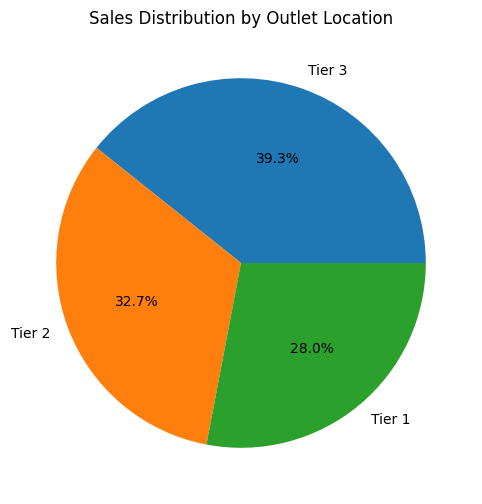

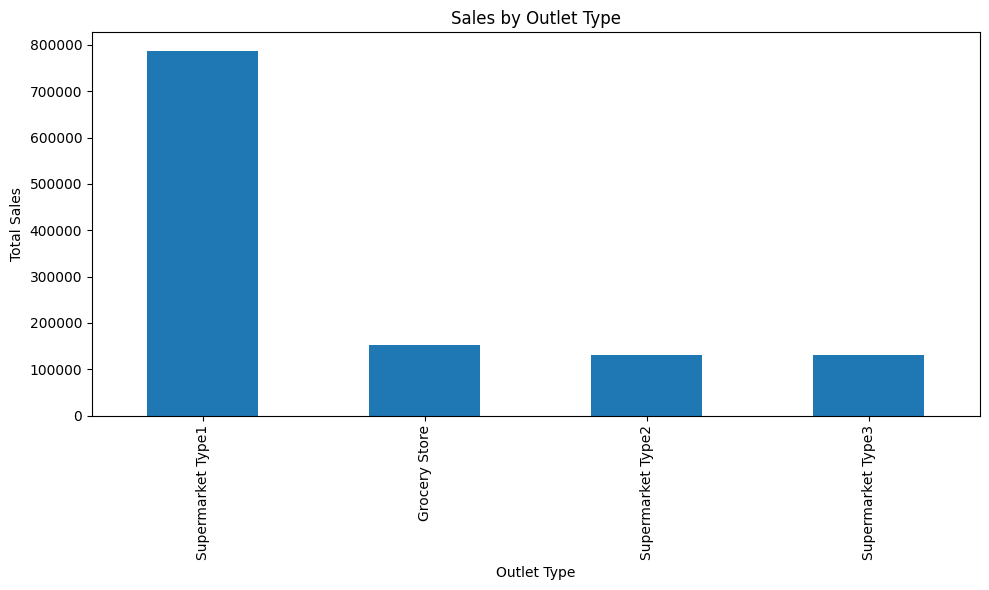

In [12]:
plt.figure(figsize=(10,6))
sales_by_item.head(10).plot(kind='bar')
plt.title("Top 10 Selling Product Categories")
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sales_by_location.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Outlet Location")
plt.ylabel("")
plt.show()

plt.figure(figsize=(10,6))
sales_by_outlet.plot(kind='bar')
plt.title("Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# CORRELATION HEATMAP

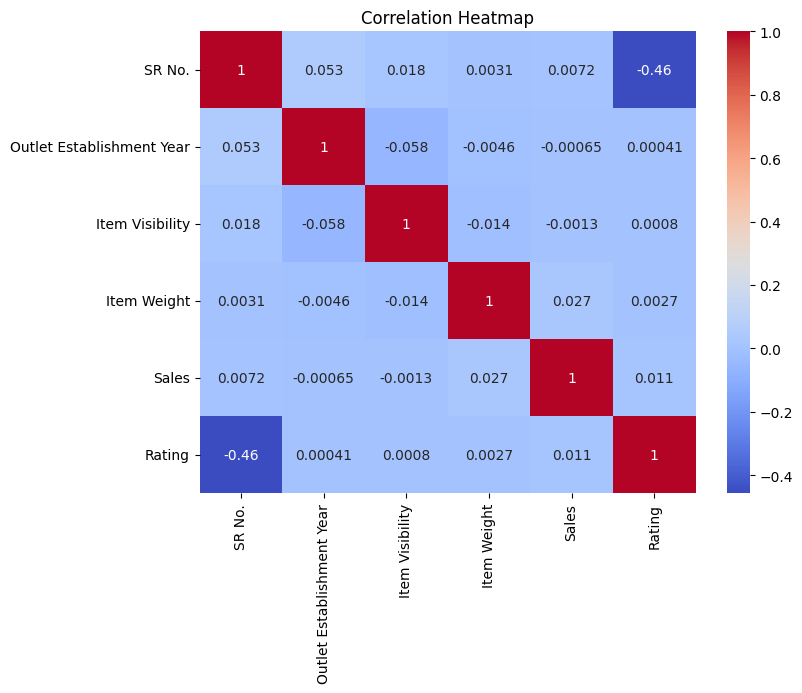

In [13]:
numeric_df = df.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# EXPORT ANALYSIS TO EXCEL

In [14]:
output_file = "blinkit_python_analysis.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:

    df.to_excel(writer, sheet_name="Raw_Data", index=False)
    sales_by_item.to_excel(writer, sheet_name="Sales_by_Item_Type")
    sales_by_location.to_excel(writer, sheet_name="Sales_by_Location")
    sales_by_outlet.to_excel(writer, sheet_name="Sales_by_Outlet_Type")
    rating_analysis.to_excel(writer, sheet_name="Rating_Analysis")

print("\nExcel analysis file created: blinkit_python_analysis.xlsx")


Excel analysis file created: blinkit_python_analysis.xlsx


In [15]:
from google.colab import files
files.download("blinkit_python_analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>